# U.S. GDP Growth Rate Curve Fitting and Interpolation Project

# Introduction

This project analyzes a dataset of U.S. quarterly real GDP growth rates from 2010 to 2023, reported as seasonally adjusted annual rates, to study how different numerical methods model economic data. The selected GDP values come from the U.S. Bureau of Economic Analysis and include both typical growth periods and extreme observations during the COVID-19 shock, making the dataset useful for comparing interpolation and approximation techniques. In this project, three methods will be applied: least squares linear regression, polynomial fitting, and natural cubic spline interpolation. Least squares regression will be used to examine overall trend behavior, polynomial fitting will be used to approximate the data with a higher-degree model, and cubic spline interpolation will be used to make a smooth curve that passes exactly through the given data points. All together, these methods provide a way to compare trend estimation, exact interpolation, smoothness, and sensitivity to economic outliers in the GDP data.

# Part A - Cubic Spline Interpolation

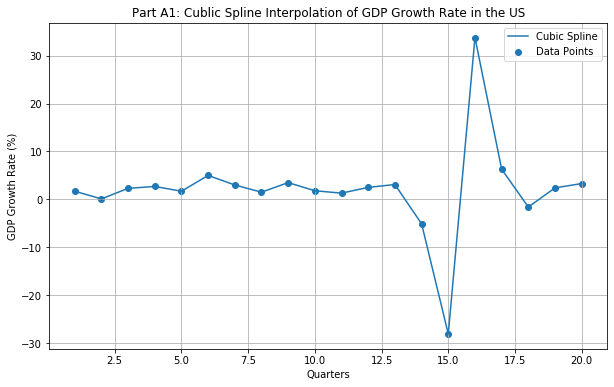

In [28]:
# Part A1 Code

import numpy as np
import matplotlib.pyplot as plt

# Data
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20])
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

# Tridiagonal System
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x) # Step sizes between data points
    
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1]                                     # Subdiagonal
        B[i - 1] = 2*(h[i-1]+h[i])                            # Main diagonal
        C[i - 1] = h[i]                                       # Superdiagonal
        D[i - 1] = 6* ((y[i+1]-y[i])/h[i]-(y[i]-y[i-1])/h[i-1]) # Right-hand side vector
    return A, B, C, D

# Thomas Algorithm 
def thomas_algorithm(a, b, c, d):
    """
        Solve the tridiagonal system using the Thomas algorithm.
        a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    
    a = a.astype(float).copy()
    b = b.astype(float).copy()
    c = c.astype(float).copy()
    d = d.astype(float).copy()

    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
        
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

# Compute Second Derivatives
def compute_second_derivatives(x, y):
    n = len(x)
    A, B, C, D = setup_tridiagonal_matrix(x, y)
    
    M = np.zeros(n)
    
    if n > 2:
        M_interior = thomas_algorithm(A[1:], B, C[:-1], D)
        M[1:n-1] = M_interior
    return M

# Evaluate the spline at a single point
def evaluate_spline_single(x, y, M, x_eval):
    n = len(x)
    
    if x_eval <= x[0]:
        i = 0
    elif x_eval >= x[-1]:
        i = n-2
    else:
        i = 0
        while i < n-1:
            if x[i] <= x_eval <= x[i+1]:
                break
            i += 1
            
    h = x[i+1] - x[i]
    
    term1 = M[i] * (x[i + 1] - x_eval) ** 3 / (6 * h)
    term2 = M[i + 1] * (x_eval - x[i]) ** 3 / (6 * h)
    term3 = (y[i] - M[i] * h ** 2 / 6) * (x[i + 1] - x_eval) / h
    term4 = (y[i + 1] - M[i + 1] * h ** 2 / 6) * (x_eval - x[i]) / h
    
    return term1 + term2 + term3 + term4

# Evaluate the spline at multiple points
def evaluate_spline(x, y, M, x_multeval):
    y_multeval = []
    
    for xe in x_multeval:
        y_multeval.append(evaluate_spline_single(x, y, M, xe))
    return y_multeval

# Program
A, B, C, D = setup_tridiagonal_matrix(x, y)
M = compute_second_derivatives(x, y)

x_eval = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], dtype=float)
y_eval = evaluate_spline(x, y, M, x_eval)

# Plot
x_plot = np.linspace(1, 20, 500)
y_plot = evaluate_spline(x, y, M, x_plot)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, label ="Data Points")
plt.plot(x_eval, y_eval, label ="Cubic Spline")

plt.xlabel("Quarters")
plt.ylabel("GDP Growth Rate (%)")
plt.title("Part A1: Cublic Spline Interpolation of GDP Growth Rate in the US")
plt.legend()
plt.grid(True)
plt.show()

Part A1 Write-up:

The dataset has 20 points with 19 spline intervals, so the spline is a piecewise function defined on [x1,x2], [x3,x4], ...,[x19,x20]. Since the unknowns are the interior second derivatives of the spline, there are 18 unknowns. At each interior knot, the spline must be continuous (the left and right components meet at the knot), the first derivative is continuous, and the second derivative must be continuous. For a natural spline, the boundary conditions are M1 = 0 and M20 = 0, which means that the second derivatives at the two endpoints are zero.

Spline evaluated at every quarter in the full range:
x = 1.0000, y = 1.700000
x = 1.3519, y = 0.800601
x = 1.7037, y = 0.186416
x = 2.0556, y = 0.142186
x = 2.4074, y = 0.768732
x = 2.7593, y = 1.704611
x = 3.1111, y = 2.519089
x = 3.4630, y = 2.930562
x = 3.8148, y = 2.899704
x = 4.1667, y = 2.420420
x = 4.5185, y = 1.774843
x = 4.8704, y = 1.553816
x = 5.2222, y = 2.299370
x = 5.5741, y = 3.706811
x = 5.9259, y = 4.871755
x = 6.2778, y = 4.997707
x = 6.6296, y = 4.210136
x = 6.9815, y = 3.060083
x = 7.3333, y = 2.053586
x = 7.6852, y = 1.475118
x = 8.0370, y = 1.544147
x = 8.3889, y = 2.285614
x = 8.7407, y = 3.155291
x = 9.0926, y = 3.508855
x = 9.4444, y = 3.070263
x = 9.7963, y = 2.253397
x = 10.1481, y = 1.541513
x = 10.5000, y = 1.194945
x = 10.8519, y = 1.200023
x = 11.2037, y = 1.519571
x = 11.5556, y = 2.007608
x = 11.9074, y = 2.429636
x = 12.2593, y = 2.589571
x = 12.6111, y = 2.664181
x = 12.9630, y = 3.029257
x = 13.3148, y = 3.609486
x = 13.6667, y = 1.839832
x = 14.0185

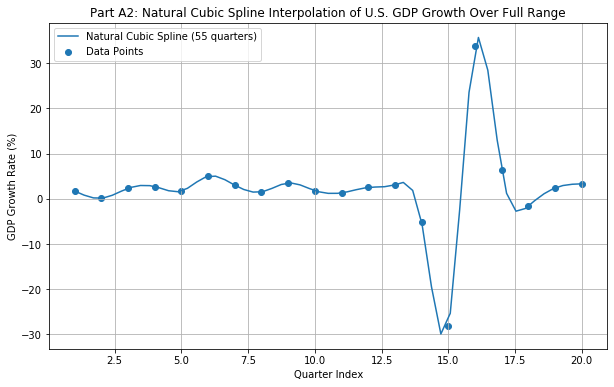

In [21]:
# Part A2 Code
# Evaluating the natural cubic spline code at every quarter in the full range

M = compute_second_derivatives(x, y)

# 55 points in the full quarterly range
x_full = np.linspace(1, 20, 55)
y_full = evaluate_spline(x, y, M, x_full)

print("Spline evaluated at every quarter in the full range:")
for i in range(len(x_full)):
    print(f"x = {x_full[i]:.4f}, y = {y_full[i]:.6f}")

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label="Data Points")
plt.plot(x_full, y_full, label="Natural Cubic Spline (55 quarters)")
plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth Rate (%)")
plt.title("Part A2: Natural Cubic Spline Interpolation of U.S. GDP Growth Over Full Range")
plt.legend()
plt.grid(True)
plt.show()

Part A2 Write-up:

Using the natural cubic spline from Part A.1, I evaluated the spline at every quarter in the full range from 2010 to 2023. The output curve in the plot is visually smooth because the natural cubic spline is continuous and has continuous first and second derivatives across the interval. Therefore, there are no sharp corners between the knots. Most of the dataset reflects a reasonably smooth line that matches the GDP growth patterns until the COVID period begins. The curve drops to -28.1% and rises back to 33.8%, changing very sharply since it must pass right through those specific points. The interpolant is mathematically smooth, but the shape in that region reflects the outlier in the dataset. Overall, the spline is mostly smooth and reasonable, but the extreme quarters make the curve steep and less representative of the long-term pattern in that specific region.

Part A3 Write-up:

The spline must pass exactly through the 2020 Q2 value which is -28.1% so that it produces the extreme fall with no error. The main strength of interpolation is that every known data point is matched exactly. However, this creates a trade-off between exact interpolation and numerical stability when the dataset contains extreme outliers. The Runge phenomenon refers to large oscillations that appear when using high-degree polynomial interpolation over many points, especially around unusual or outlying values. A cubic spline is more stable than one global high-degree polynomial because it uses low-degree cubic pieces locally, so it reduces the problem put forth by the Runge phenomenon. However, a spline is still an exact interpolant, so an extreme value like -28.1% forces the curve to bend sharply in that area.

For the dataset, the issue is that exact interpolation makes the local shape highly sensitive to unusual observations. The curve near 2020 Q2 and 2020 Q3 reflects the pandemic shock and rebound exactly, which is useful if the goal is to preserve the recorded data, but it may distort the broader economic pattern if the goal is trend analysis. The trade-off is that exact interpolation preserves all observations, while more approximate methods improve stability and reduce sensitivity to outliers. In this case, a smoothing spline or weighted least squares could be preferable if the goal is to model the general trend rather than map the entire curve out through every extreme point. A smoothing spline would shrink the exact fit and produce a smoother curve overall, while weighted least squares would allow extreme quarters such as 2020 Q2 and 2020 Q3 to have less influence on the fitted model. So for exact interpolation of each quarter, the natural cubic spline is appropriate, but for a more stable representation of long-run GDP behavior, smoothing splines or weighted least squares would likely be better choices.

# Part B - Polynomial & Least Squares Comparison

Part B1:
Degree 4 Polynomial Coefficients:
[-1.17213791e-03  5.44711952e-02 -8.23719896e-01  4.44241917e+00
 -4.13737100e+00]
Degree 4 Polynomial RMSE: 9.965326786519533



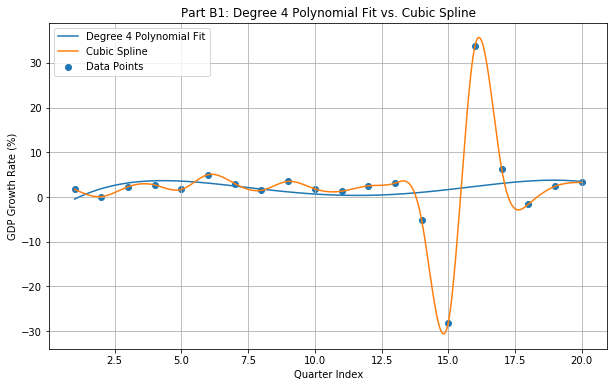

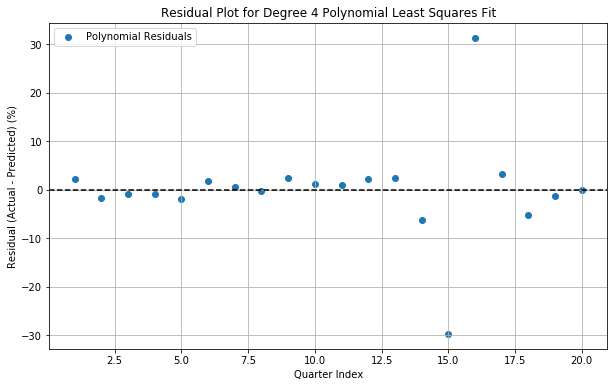

In [19]:
# Part B1 Code

import numpy as np
import matplotlib.pyplot as plt

# Data
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20])
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

# Least Squares Polynomial Fit
def vandermonde_matrix(x, degree):
    n = len(x)
    A = np.zeros((n, degree + 1))
    
    for i in range(n):
        for j in range(degree + 1):
            A[i, j] = x[i]**(degree - j)
    return A

def polynomial_least_squares(x, y, degree):
    A = vandermonde_matrix(x, degree)
    ATA = A.T @ A
    ATy = A.T @ y
    coefficients = np.linalg.solve(ATA, ATy)
    return coefficients

def evaluate_polynomial_point(coefficients, x_value):
    y_value = 0.0
    degree = len(coefficients) - 1
    
    for i in range(len(coefficients)):
        power = degree - i
        y_value += coefficients[i]*(x_value**power)
    return y_value

def evaluate_polynomial(coefficients, x_values):
    y_values = []

    for xv in x_values:
        y_values.append(evaluate_polynomial_point(coefficients, xv))

    return np.array(y_values)

# Residuals
def compute_residuals(y_actual, y_predicted):
    residuals = []
    for i in range(len(y_actual)):
        residuals.append(y_actual[i] - y_predicted[i])
    return np.array(residuals)

def compute_rmse(residuals):
    total = 0.0
    for r in residuals:
        total += r**2
    return (total/len(residuals))**0.5

# Degree 4 Polynomial vs Cubic Spline
degree = 4
polynomial_coefficients = polynomial_least_squares(x, y, degree)

M = compute_second_derivatives(x, y)

x_plot = np.linspace(1, 20, 500)
y_polyplot = evaluate_polynomial(polynomial_coefficients, x_plot)
y_splineplot = evaluate_spline(x, y, M, x_plot)

y_polyatpoint = evaluate_polynomial(polynomial_coefficients, x)
polynomial_residuals = compute_residuals(y, y_polyatpoint)
polynomial_rmse = compute_rmse(polynomial_residuals)

print("Part B1:")
print("Degree 4 Polynomial Coefficients:")
print(polynomial_coefficients)
print("Degree 4 Polynomial RMSE:", polynomial_rmse)
print()

# Plot Polynomial Least Squares vs Cubic Spline
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label="Data Points")
plt.plot(x_plot, y_polyplot, label="Degree 4 Polynomial Fit")
plt.plot(x_plot, y_splineplot, label="Cubic Spline")
plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth Rate (%)")
plt.title("Part B1: Degree 4 Polynomial Fit vs. Cubic Spline")
plt.legend()
plt.grid(True)
plt.show

# Plot Polynomial Residuals
plt.figure(figsize=(10, 6))
plt.scatter(x, polynomial_residuals, label="Polynomial Residuals")
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Quarter Index")
plt.ylabel("Residual (Actual - Predicted) (%)")
plt.title("Residual Plot for Degree 4 Polynomial Least Squares Fit")
plt.legend()
plt.grid(True)
plt.show()


Part B1 Write-up:

The 4th degree polynomial fit model captures the overall trend better than the cubic spline because the least squares method smooths the data instead of forcing the curve through every single point. This makes the polynomial fit useful for showing the movement of GDP growth across the selected quarters. However, the cubic spline better reproduces specific data points because it is an interpolant and passes through every observation, including the extreme drop to -28.1% and rebound to 33.8%. 

The two methods highlight a trade-off between approximation and interpolation. The 4th degree polynomial fit is an approximation method because it does not match each point exactly, but it produces a smooth global curve that is less sensitive to fluctuations. The cubic spline is an interpolation method because it fits every point exactly and preserves local behavior. However, it is more influenced by unusual values, such as the extreme COVID quarter data points. In conclusion, the polynomial fit is better for summarizing the overall trend, while the spline is better for reproducing the exact data points.

Part B2:
Linear least squares slope: -0.017336448598130803
Linear least squares intercept: 2.3041121495327097
Linear RMSE: 1.4400212550352411



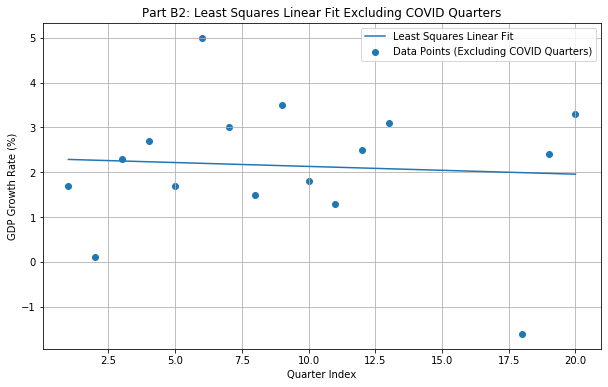

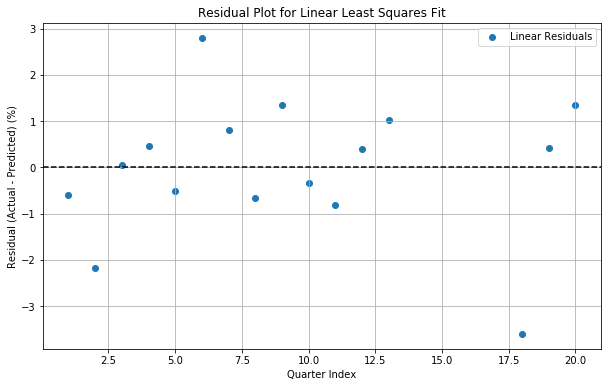

In [25]:
# Part B2 Code

# Least Squares Linear Fit
def linear_least_squares(x, y):
    n = len(x)
    A = np.zeros((n, 2))
    
    for i in range(n):
        A[i, 0] = x[i]
        A[i, 1] = 1.0
        
    ATA = A.T @ A
    ATy = A.T @ y
    solution = np.linalg.solve(ATA, ATy)
    
    m = solution[0]
    b = solution[1]
    
    return m, b

def evaluate_linear_point(m, b, x_value):
    return m * x_value + b

def evaluate_linear(m, b, x_values):
    y_values = []
    for xv in x_values:
        y_values.append(evaluate_linear_point(m, b, xv))
    return np.array(y_values)

# Residuals
def compute_residuals(y_actual, y_predicted):
    residuals = []
    for i in range(len(y_actual)):
        residuals.append(y_actual[i] - y_predicted[i])
    return np.array(residuals)

def compute_rmse(residuals):
    total = 0.0
    for r in residuals:
        total += r ** 2
    return (total / len(residuals)) ** 0.5

# Linear Least Squares excluding COVID quarters
x_linear = []
y_linear = []

for i in range(len(x)):
    if x[i] not in [14, 15, 16, 17]:
        x_linear.append(x[i])
        y_linear.append(y[i])
        
x_linear = np.array(x_linear, dtype=float)
y_linear = np.array(y_linear, dtype=float)

m, b = linear_least_squares(x_linear, y_linear)

x_linear_plot = np.linspace(min(x_linear), max(x_linear), 500)
y_linear_plot = evaluate_linear(m, b, x_linear_plot)

y_linear_at_point = evaluate_linear(m, b, x_linear)
linear_residuals = compute_residuals(y_linear, y_linear_at_point)
linear_rmse = compute_rmse(linear_residuals)

print("Part B2:")
print("Linear least squares slope:", m)
print("Linear least squares intercept:", b)
print("Linear RMSE:", linear_rmse)
print()

# Plot Linear Least Squares
plt.figure(figsize=(10, 6))
plt.scatter(x_linear, y_linear, label="Data Points (Excluding COVID Quarters)")
plt.plot(x_linear_plot, y_linear_plot, label="Least Squares Linear Fit")
plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth Rate (%)")
plt.title("Part B2: Least Squares Linear Fit Excluding COVID Quarters")
plt.legend()
plt.grid(True)
plt.show()

# Plot Linear Residuals
plt.figure(figsize=(10, 6))
plt.scatter(x_linear, linear_residuals, label="Linear Residuals")
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Quarter Index")
plt.ylabel("Residual (Actual - Predicted) (%)")
plt.title("Residual Plot for Linear Least Squares Fit")
plt.legend()
plt.grid(True)
plt.show()

Part B2 Write-up:

The slope for the least squares linear model excluding the COVID quarters is -0.017336448598130803. This slope represents the average rate of change in GDP growth per quarter over the remaining data. Since the extreme quarters during the pandemic are removed, the fitted line reflects the more typical pattern rather than the temporary extreme period. 

A linear trend has limited economic meaning for the dataset. It can give a summary of whether GDP growth is increasing or decreasing on average over time, but quarterly GDP growth is not naturally linear. Economic growth changes because of business cycles, shocks, recoveries, and external factors, so a straight-line model is a simplification instead of a realistic model. In summary, the linear fit may be useful as a basic trend summary, but it should not be used as a complete description of economic behavior.

The linear model assumes that the relationship between quarter index and GDP growth is approximately linear over the selected period. It also assumes that deviations from the line are random rather than systematic. Additionally, the model assumes that the excluded COVID quarters are treated as outliers rather than part of the long-term pattern. Lastly, it assumes that the remaining quarters are representative enough for a single line to represent them.

# Part C - Method Justification

Part C Write-up: 

For a policymaker who needs to estimate GDP growth between two known data points, I would recommend the cubic spline method rather than the polynomial fit. The main reason I would suggest this is that cubic spline interpolation is designed to produce a smooth curve between data points while preserving the known values at the data points. In this project, the spline is continuous in value, first derivative, and second derivative, so it shows a smooth and realistic transition between quarters. On the other hand, the 4th degree polynomial is a least squares approximation, so it highlights the overall trend but does not reproduce the local behavior between nearby points as accurately. From the earlier comparisons, the polynomial fit is better for showing the broad pattern of GDP growth, while the spline better matches the specific structure of the data. Therefore, the cubic spline is the better choice for interpolation.

In terms of accuracy, the cubic spline is preferable because it passes exactly through the known data points, so the estimates between those points are reflected locally by the nearest observations. A polynomial fit does not pass through every point, so its interpolated values may be pulled away by extreme data points. This is very important when the dataset contains extreme values, like the COVID period value. When referring to how sensitive each method is to outliers, both methods are affected, but in their own ways. The spline is locally sensitive, which means that an extreme value mainly distorts the nearby intervals. The polynomial fit is globally sensitive, which means that one unusual quarter can influence the shape of the entire curve. For policymaking between two known neighboring points, local behavior is more important than global approximation, so the spline is still the better option.

Input sizes: [20, 40, 80, 160, 320, 640, 1280]
Average cubic spline times: [0.00044058728963136673, 0.0010603100061416626, 0.0024253245443105697, 0.007602304220199585, 0.0245199890807271, 0.09316544272005559, 0.3637694790959358]
Average polynomial least squares times: [0.00024290196597576141, 0.00039890184998512266, 0.0006927760317921638, 0.00131092369556427, 0.0023964140564203262, 0.004839156568050384, 0.009813503921031952]
Average linear least squares times: [7.212590426206589e-05, 9.137820452451706e-05, 0.00016205664724111557, 0.0002677351236343384, 0.000349484384059906, 0.0006113598123192787, 0.0011434542015194894]


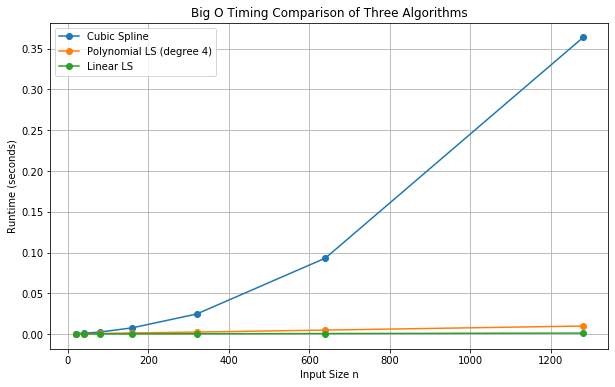

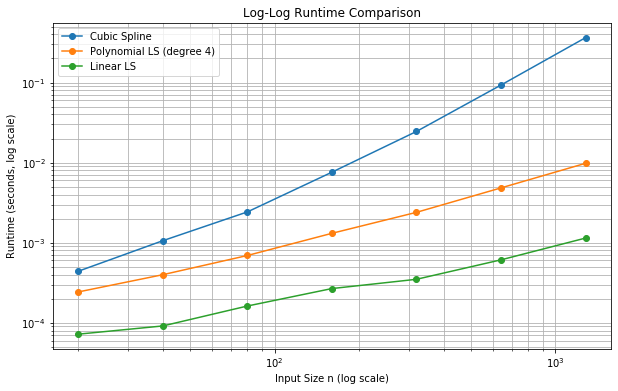

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Data Generator
def generate_test_data(n):
    x = np.linspace(1, n, n)
    y = 2.0 * np.sin(0.1 * x) + 0.5 * x / n + np.random.normal(0, 0.1, n)
    return x, y

# Time the functions
# Cubic Spline
def time_cubic_spline(n):
    x, y = generate_test_data(n)
    x_eval = np.linspace(1, n, n)

    start = time.perf_counter()
    M = compute_second_derivatives(x, y)
    y_eval = evaluate_spline(x, y, M, x_eval)
    end = time.perf_counter()

    return end - start

# Polynomial Fit
def time_polynomial_fit(n, degree=4):
    x, y = generate_test_data(n)
    x_eval = np.linspace(1, n, n)

    start = time.perf_counter()
    coefficients = polynomial_least_squares(x, y, degree)
    y_eval = evaluate_polynomial(coefficients, x_eval)
    end = time.perf_counter()

    return end - start

# Linear Least Squares
def time_linear_fit(n):
    x, y = generate_test_data(n)

    start = time.perf_counter()
    m, b = linear_least_squares(x, y)
    y_eval = evaluate_linear(m, b, x)
    end = time.perf_counter()

    return end - start

# Big O
sizes = [20, 40, 80, 160, 320, 640, 1280]

spline_times = []
poly_times = []
linear_times = []

num_trials = 5

for n in sizes:
    spline_total = 0.0
    poly_total = 0.0
    linear_total = 0.0

    for _ in range(num_trials):
        spline_total += time_cubic_spline(n)
        poly_total += time_polynomial_fit(n)
        linear_total += time_linear_fit(n)

    spline_times.append(spline_total / num_trials)
    poly_times.append(poly_total / num_trials)
    linear_times.append(linear_total / num_trials)

print("Input sizes:", sizes)
print("Average cubic spline times:", spline_times)
print("Average polynomial least squares times:", poly_times)
print("Average linear least squares times:", linear_times)

# Plot Runtime vs Input Size
plt.figure(figsize=(10, 6))
plt.plot(sizes, spline_times, marker='o', label='Cubic Spline')
plt.plot(sizes, poly_times, marker='o', label='Polynomial LS (degree 4)')
plt.plot(sizes, linear_times, marker='o', label='Linear LS')
plt.xlabel('Input Size n')
plt.ylabel('Runtime (seconds)')
plt.title('Big O Timing Comparison of Three Algorithms')
plt.legend()
plt.grid(True)
plt.show()

# Log-Log Plot
plt.figure(figsize=(10, 6))
plt.loglog(sizes, spline_times, marker='o', label='Cubic Spline')
plt.loglog(sizes, poly_times, marker='o', label='Polynomial LS (degree 4)')
plt.loglog(sizes, linear_times, marker='o', label='Linear LS')
plt.xlabel('Input Size n (log scale)')
plt.ylabel('Runtime (seconds, log scale)')
plt.title('Log-Log Runtime Comparison')
plt.legend()
plt.grid(True, which='both')
plt.show()

Big O Write-up: 

Big O notation describes how the runtime of an algorithm grows as the input size, n, increases. It focuses on the dominant growth rate rather than the exact runtime. In this project, I tested the cubic spline algorithm, the 4th degree polynomial least squares fit, and the linear least squares fit by measuring runtime for increasing values of n.

The O(n) complexity for all three algorithms is shown in the graph above. It shows the lines for all three algorithms scaling linearly. Since all 3 methods require the same amount of time, my original recommendation is to use the spline to estimate GDP growth between two known quarters.

# Conclusion

In conclusion, the method that performed best for interpolation was the natural cubic spline because it produced a smooth curve and passed exactly through the known GDP data points. This makes it the most appropriate choice for estimating values between observed quarters. For analyzing trends, the least squares methods were more useful, especially the polynomial and linear fits, because they approximated the overall pattern of the data without forcing an exact match to every point. The 4th degree polynomial fit captured the broad movement of the dataset better than the spline, while the linear least squares model provided a simple summary of the long-run direction once the extreme COVID quarters were removed. This project also showed the limitations of each approach. I learned that cubic splines are accurate for interpolation but can be strongly affected by extreme outliers because they must pass through them exactly. Additionally, polynomial fits can smooth the data but may miss important local behavior and can become unstable for higher degrees. And lastly, linear least squares is easy to interpret but may oversimplify economic data that does not follow a straight-line trend. Overall, the project demonstrated that the best method depends on the goal. Splines are best for local interpolation while least squares methods are better for identifying broader economic trends and reducing sensitivity to extreme values.